## loading necessary libs

In [1]:
# !pip install "alphatims[plotting]"
# !pip install hvplot
# !pip install jupyter_bokeh
# !pip install dask[dataframe]
# !pip install matplotlib
# !pip install scikit-learn

In [9]:
import alphatims.utils
import alphatims.bruker
import alphatims.plotting
import importlib
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import seaborn as sns



### Loading Data

In [10]:


alphatims.utils.set_threads(4)
log_file_name = alphatims.utils.set_logger(
    log_file_name="tutorial_log.txt",
    overwrite=True
)

def reload():
    importlib.reload(alphatims.utils)
    importlib.reload(alphatims.bruker)
    importlib.reload(alphatims.plotting)
    alphatims.utils.set_threads(4)
    alphatims.utils.set_logger(log_file_name="tutorial_log.txt")
    
isDia = True

if (isDia):
    bruker_d_folder_name = "../MS_Data/test1.hdf"
    
else :
    bruker_d_folder_name = ""

data = alphatims.bruker.TimsTOF(bruker_d_folder_name)

2025-03-31 17:59:04> Importing data from ../MS_Data/test1.hdf
2025-03-31 17:59:04> Using HDF import for ../MS_Data/test1.hdf
2025-03-31 17:59:05> Successfully imported data from ../MS_Data/test1.hdf


In [11]:
selected_indices = data[:,:,0, 400.0: 425.0,"raw"]

In [12]:

intensities =data.bin_intensities(selected_indices,("rt_values","mz_values"))
intensities

max_index :  {'rt_values': 3177, 'mobility_values': 928, 'mz_values': 197268}
parsed_indices :  {'frame_indices': array([   1,    1,    1, ..., 3176, 3176, 3176]), 'tof_indices': array([127662, 132644, 130823, ..., 128881, 129883, 133525], dtype=uint32)}


MemoryError: Unable to allocate 4.67 GiB for an array with shape (3177, 197268) and data type float64

## Plotting

In [6]:
def plot_lineplot(x_dim,y_dim,selected_indices):
        if data is not None:  # Ensure dataset is loaded
            # Validate selected dimensions
            valid_x_dims = ['mz', 'rt', 'mobility']
            valid_y_dims = ['intensity', 'mz', 'rt', 'mobility']
            if x_dim in valid_x_dims and y_dim in valid_y_dims: 
                # Create the plot
                plot = alphatims.plotting.line_plot(
                    data,
                    selected_indices,
                    x_dim,
                    data.sample_name,
                    y_dim
                )
                print("acquisition_mode: ",data.acquisition_mode)
                return plot  # Dynamically update the plot
            else:
                return "Invalid dimensions selected."
        else:
            return "Dataset is not loaded."

In [7]:
dimensions = ("rt_values","mz_values")
intensities = data.bin_intensities(selected_indices, dimensions)
intensities

max_index :  {'rt_values': 3177, 'mobility_values': 928, 'mz_values': 197268}
parsed_indices :  {'frame_indices': array([   1,    1,    1, ..., 3176, 3176, 3176]), 'tof_indices': array([127662, 132644, 130823, ..., 128881, 129883, 133525], dtype=uint32)}


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

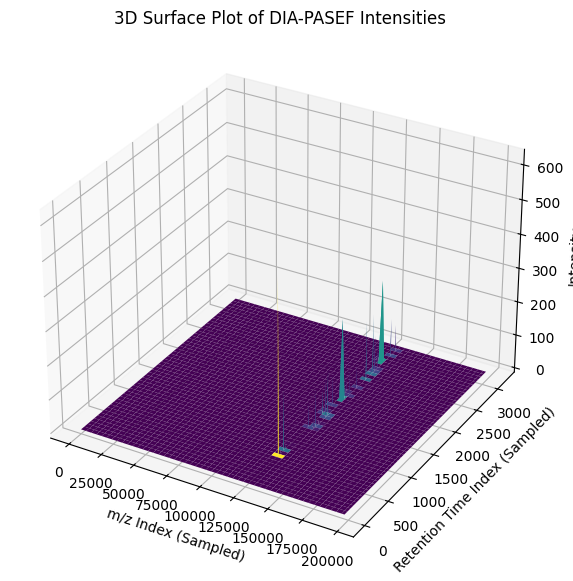

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define downsampling factors (Adjust as needed)
x_indices = np.linspace(0, intensities.shape[1] - 1, num=100, dtype=int)  # m/z index (sampled)
y_indices = np.linspace(0, intensities.shape[0] - 1, num=500, dtype=int)  # rt index (sampled)

# Create meshgrid for plotting
X, Y = np.meshgrid(x_indices, y_indices)

# Extract the downsampled intensity values
intensities_small = intensities[np.ix_(y_indices, x_indices)]

# Create 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, intensities_small, cmap='viridis')

ax.set_xlabel("m/z Index (Sampled)")
ax.set_ylabel("Retention Time Index (Sampled)")
ax.set_zlabel("Intensity")
ax.set_title("3D Surface Plot of DIA-PASEF Intensities")

plt.show()
